In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!ls /content/drive/MyDrive/autosort-ai

agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    predictions.csv
Bitext_Sample_Customer_Service_Validation_Dataset.csv  README.md
classifier.ipynb				       requirements.gdoc


In [16]:
!pip install nbformat

In [17]:
import nbformat
from IPython import get_ipython

def run_notebook(path):
    with open(path) as f:
        nb = nbformat.read(f, as_version=4)
        ip = get_ipython()
        for cell in nb.cells:
            if cell.cell_type == 'code':
                ip.run_cell(cell.source)

In [18]:
run_notebook('/content/drive/MyDrive/autosort-ai/db.ipynb')

In [19]:
run_notebook('/content/drive/MyDrive/autosort-ai/agent.ipynb')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    predictions.csv
Bitext_Sample_Customer_Service_Validation_Dataset.csv  README.md
classifier.ipynb				       requirements.gdoc


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    predictions.csv
Bitext_Sample_Customer_Service_Validation_Dataset.csv  README.md
classifier.ipynb				       requirements.gdoc
Total samples: 8175


,utterance,intent,category,tags
0,would it be possible to cancel the order I made?,cancel_order,ORDER,BIP
1,cancelling order,cancel_order,ORDER,BK
2,I need assistance canceling the last order I h...,cancel_order,ORDER,B
3,problem with canceling the order I made,cancel_order,ORDER,B
4,I don't know how to cancel the order I made,cancel_order,ORDER,B


<ipython-input-20-449a56fffb77>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=intent_counts.index, x=intent_counts.values, palette="viridis")


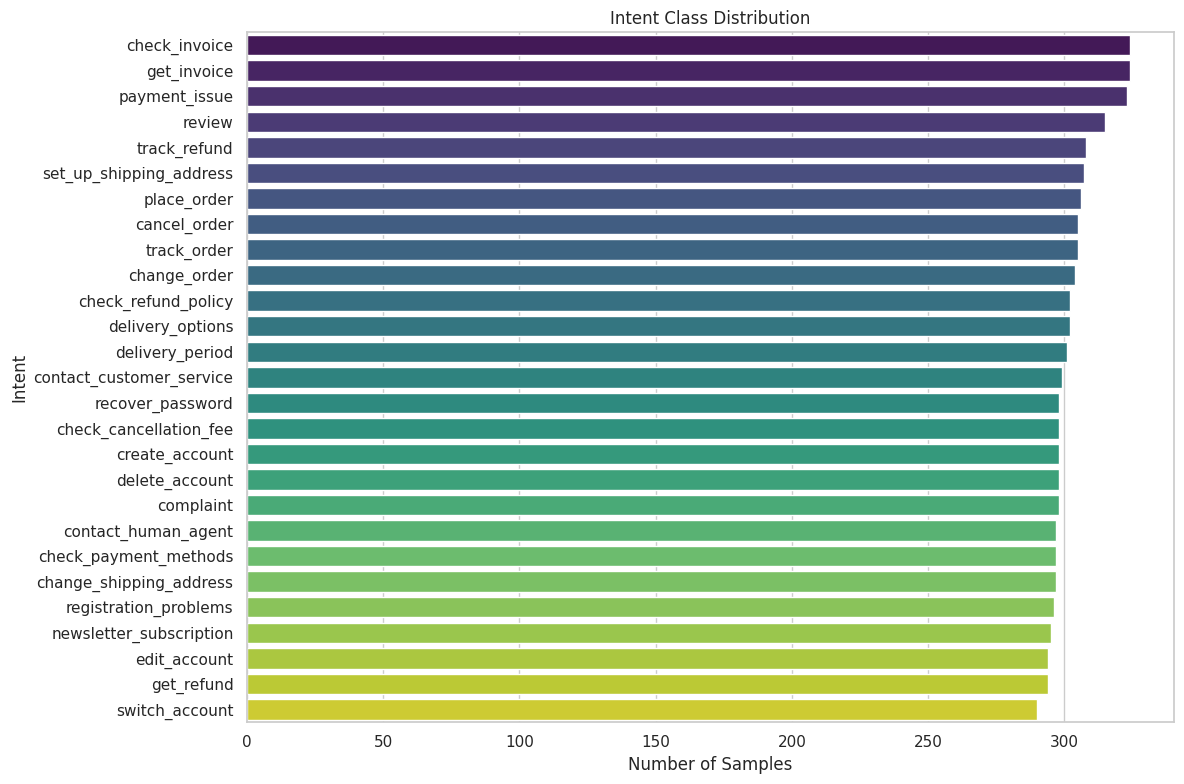

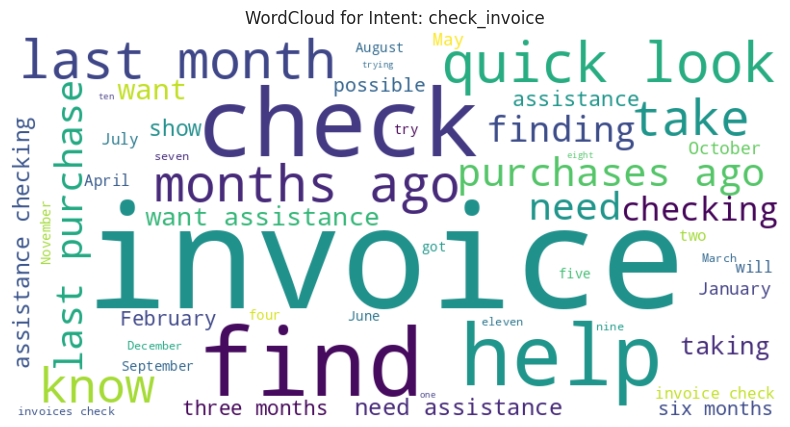

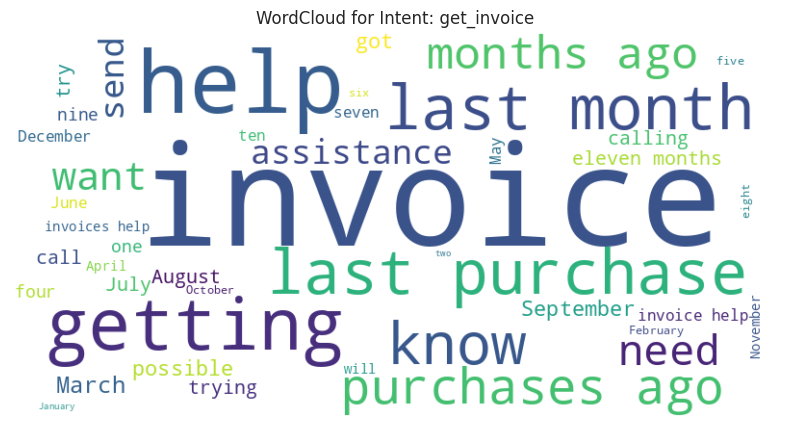

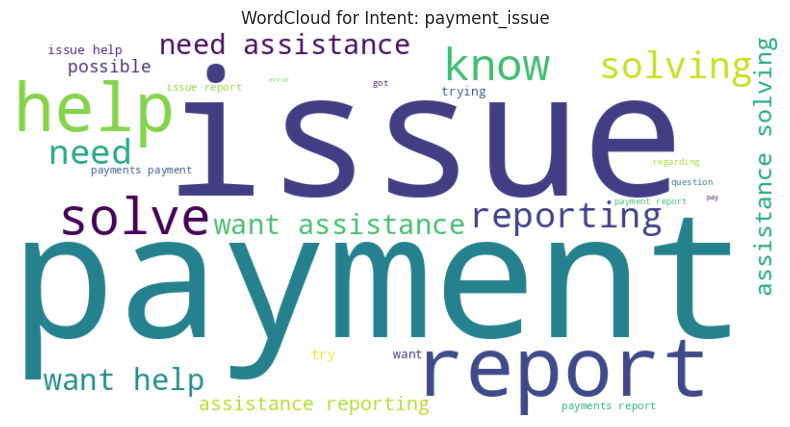


🗂 Words for Intent: check_invoice (87 unique words):
['1', '10', '11', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'ago', 'am', 'april', 'assistance', 'at', 'august', 'be', 'can', 'cannot', 'check', 'checking', 'could', 'december', 'do', 'don', 'eight', 'eleven', 'february', 'find', 'finding', 'five', 'four', 'from', 'got', 'have', 'help', 'how', 'i', 'invoice', 'invoices', 'is', 'it', 'january', 'july', 'june', 'know', 'last', 'like', 'look', 'march', 'may', 'me', 'month', 'months', 'my', 'need', 'nine', 'not', 'november', 'october', 'one', 'possible', 'purchase', 'purchases', 'quick', 'september', 'seven', 'show', 'six', 't', 'take', 'taking', 'ten', 'the', 'three', 'to', 'try', 'trying', 'two', 'want', 'what', 'where', 'will', 'would', 'you']

🗂 Words for Intent: get_invoice (78 unique words):
['1', '10', '11', '2', '3', '5', '6', '7', '8', '9', 'ago', 'am', 'april', 'assistance', 'august', 'be', 'call', 'calling', 'can', 'could', 'december', 'do', 'don', 'eight', 'eleven', 'febru

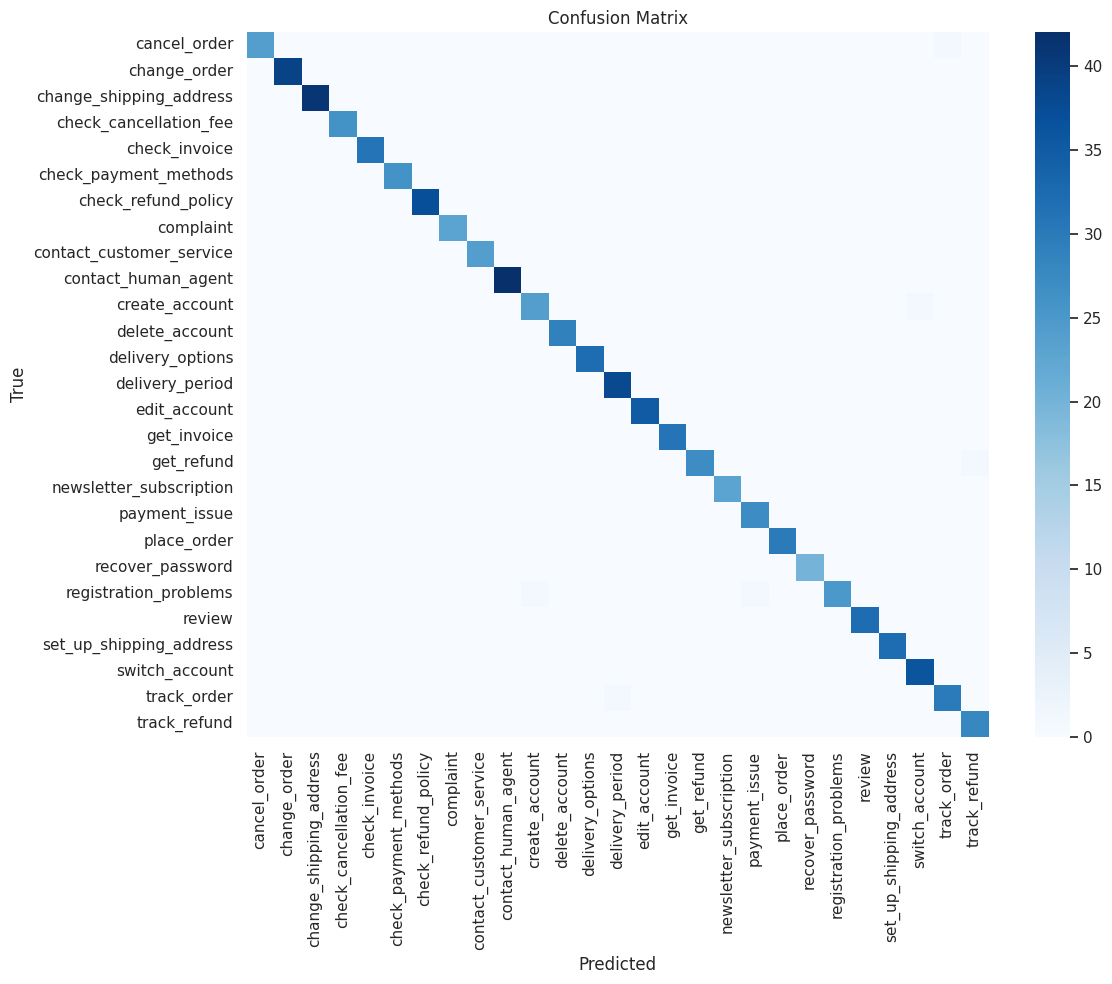

In [20]:
run_notebook('/content/drive/MyDrive/autosort-ai/analysis.ipynb')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
agent.ipynb					       db.ipynb
analysis.ipynb					       intent_classifier.pkl
Bitext_Sample_Customer_Service_Testing_Dataset.csv     main.ipynb
Bitext_Sample_Customer_Service_Training_Dataset.csv    predictions.csv
Bitext_Sample_Customer_Service_Validation_Dataset.csv  README.md
classifier.ipynb				       requirements.gdoc

 Validation Results:
                          precision    recall  f1-score   support

            cancel_order       0.97      1.00      0.99        34
            change_order       1.00      1.00      1.00        33
 change_shipping_address       1.00      1.00      1.00        28
  check_cancellation_fee       1.00      1.00      1.00        26
           check_invoice       1.00      1.00      1.00        35
   check_payment_methods       1.00      1.00      1.00        25
     check_refund_policy       0.96      1.00      0.98    

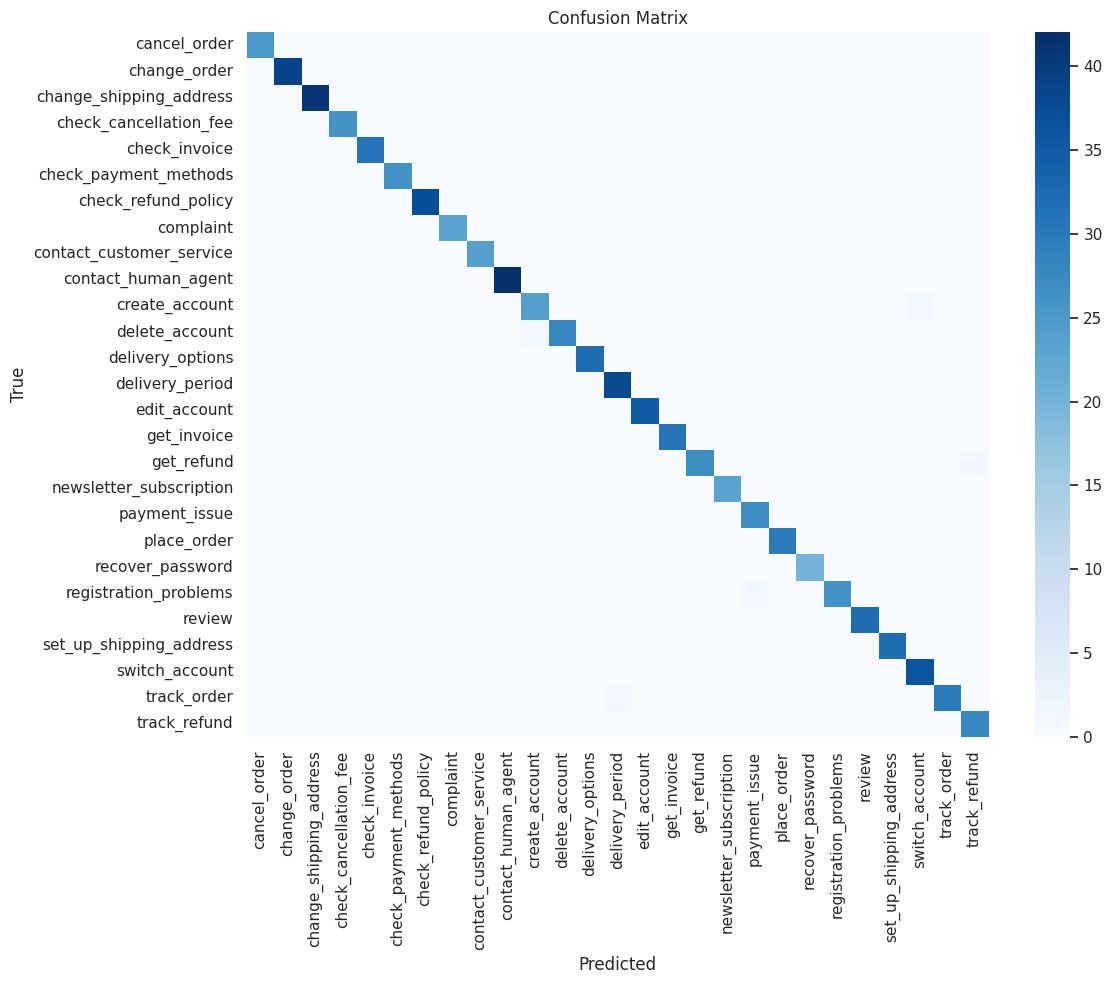

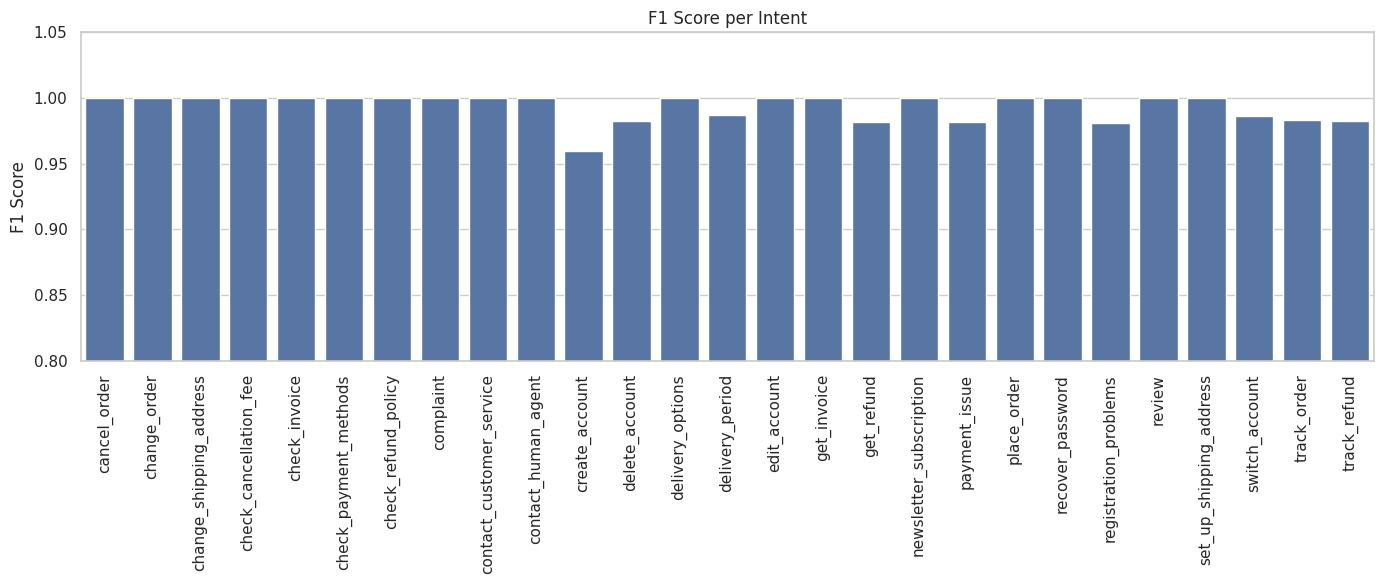

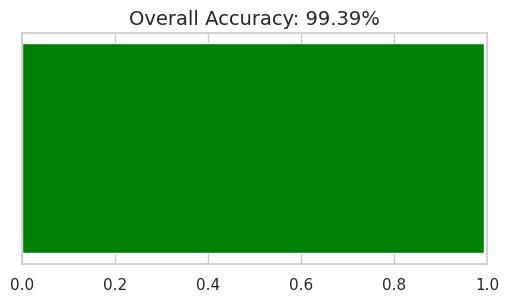

✅ Model saved to /content/drive/MyDrive/autosort-ai/intent_classifier.pkl


In [21]:
run_notebook('/content/drive/MyDrive/autosort-ai/classifier.ipynb')

In [22]:
import joblib
from google.colab import drive

# Mount Drive and load model
drive.mount('/content/drive')

model_bundle = joblib.load("/content/drive/MyDrive/autosort-ai/intent_classifier.pkl")
model = model_bundle["pipeline"]
label_encoder = model_bundle["label_encoder"]

# Prediction function
def predict_intent(text):
    pred = model.predict([text])
    return label_encoder.inverse_transform(pred)[0]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
user_id = init_user()

print("\n AutoSortAI Response")

query = input("\n Enter your query:")

intent = predict_intent(query)
response = agent_response(intent)

save_interaction(user_id, query, intent, response)

print(f"💬 Response: {response['response']}")


 AutoSortAI Response

 Enter your query:I wanna cancel order
💬 Response: I'm not sure, let me connect you with a human agent.


In [28]:
# 📜 Show saved DB
print("\n📝 All Saved Logs:")
for entry in get_user_history(user_id):
    print(entry)


📝 All Saved Logs:
{'query': 'I wanna cancel order', 'intent': 'cancel_order', 'response': {'intent': np.int64(20), 'response': "I'm not sure, let me connect you with a human agent."}, 'timestamp': '2025-05-31T05:11:39.936770'}
